=== REQUISITO 1: LEITURA E DIAGNÓSTICO (20% DA NOTA) ===
Dimensões originais da base: (110527, 14) linhas e (110527, 14) colunas.

Valores nulos iniciais por coluna:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

=== REQUISITO 2: TRATAMENTO E TRANSFORMAÇÃO (25% DA NOTA) ===
Base limpa, tratada e transformada com sucesso!
Novas dimensões pós-faxina: (110521, 18) linhas.

=== REQUISITO 3: ANÁLISE EXPLORATÓRIA AVANÇADA (30% DA NOTA) ===
Comparativo do Tempo de Espera por Status de Comparecimento (No = Foi, Yes = Faltou):
  No-show       mean  median  count
0      No   8.754759     2.0  88207
1     Yes  15.835484    11.0  22314


C:\Users\Filmath\AppData\Local\Temp\ipykernel_7316\3682752946.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='No-show', y='WaitTime', data=df, showfliers=False, palette='Set2')


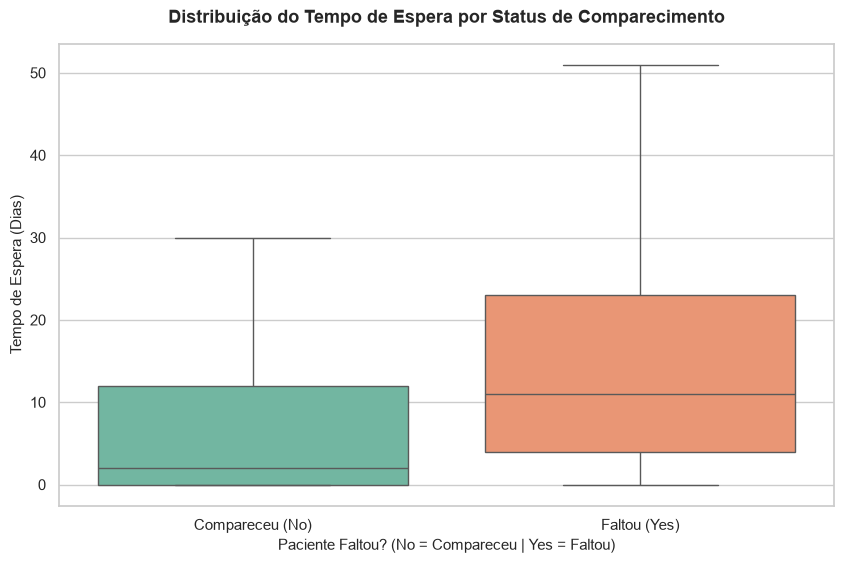

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurando o estilo visual dos gráficos (Garante o critério de Comunicação)
sns.set_theme(style="whitegrid")

print("=== REQUISITO 1: LEITURA E DIAGNÓSTICO (20% DA NOTA) ===")

# SOLUÇÃO DE CAMINHO: Mapeamento dinâmico que funciona em qualquer computador do grupo
pasta_atual = os.getcwd()
if os.path.basename(pasta_atual) == 'notebooks':
    caminho_csv = os.path.join(pasta_atual, '..', 'dados', 'KaggleV2-May-2016.csv')
else:
    caminho_csv = os.path.join(pasta_atual, 'dados', 'KaggleV2-May-2016.csv')

df = pd.read_csv(caminho_csv)

print(f"Dimensões originais da base: {df.shape} linhas e {df.shape} colunas.\n")
print("Valores nulos iniciais por coluna:")
print(df.isnull().sum())

print("\n=== REQUISITO 2: TRATAMENTO E TRANSFORMAÇÃO (25% DA NOTA) ===")

# 1. Corrigindo erros de digitação nas colunas originais do Kaggle
df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap'}, inplace=True)

# 2. Removendo idades impossíveis (Idades negativas na base original)
df = df[df['Age'] >= 0]

# 3. Padronizando a coluna Handicap para binária (0 ou 1) usando NumPy
df['Handicap'] = np.where(df['Handicap'] > 0, 1, 0)

# 4. Manipulação Temporal (Tratando as inconsistências de datas)
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.normalize()
df['ScheduledDay_date'] = df['ScheduledDay'].dt.normalize()

# Mantém apenas registros lógicos (consultas marcadas antes ou no mesmo dia do atendimento)
df = df[df['ScheduledDay_date'] <= df['AppointmentDay']]

# --- CRIAÇÃO DE COLUNAS DERIVADAS (Mínimo de 3 exigido pela Rubrica) ---
# Coluna 1: Tempo de espera em dias corridos até a consulta
df['WaitTime'] = (df['AppointmentDay'] - df['ScheduledDay_date']).dt.days

# Coluna 2: Dia da semana da consulta por extenso
df['DayOfWeek'] = df['AppointmentDay'].dt.day_name()

# Coluna 3: Faixas Etárias estruturadas com pd.cut
bins = [-1, 12, 18, 60, 120]
labels = ['Criança', 'Adolescente', 'Adulto', 'Idoso']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print("Base limpa, tratada e transformada com sucesso!")
print(f"Novas dimensões pós-faxina: {df.shape} linhas.\n")

print("=== REQUISITO 3: ANÁLISE EXPLORATÓRIA AVANÇADA (30% DA NOTA) ===")

# Agrupamento Avançado (groupby com agregação múltipla para responder à Pergunta 1)
espera_por_status = df.groupby('No-show')['WaitTime'].agg(['mean', 'median', 'count']).reset_index()
print("Comparativo do Tempo de Espera por Status de Comparecimento (No = Foi, Yes = Faltou):")
print(espera_por_status)

# Geração do Gráfico Obrigatório (Boxplot customizado sem os pontos extremos/outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(x='No-show', y='WaitTime', data=df, showfliers=False, palette='Set2')

plt.title('Distribuição do Tempo de Espera por Status de Comparecimento', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Paciente Faltou? (No = Compareceu | Yes = Faltou)', fontsize=11)
plt.ylabel('Tempo de Espera (Dias)', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Compareceu (No)', 'Faltou (Yes)'])


plt.show()


=== ANÁLISE DE RISCO POR SMS E FAIXA ETÁRIA ===

Taxa de Faltas (%) cruzando SMS e Faixas Etárias:
AgeGroup        Criança  Adolescente     Adulto      Idoso
SMS_received                                              
0             16.743363    23.050459  16.996816  13.522250
1             28.686834    34.316841  29.210678  19.222071


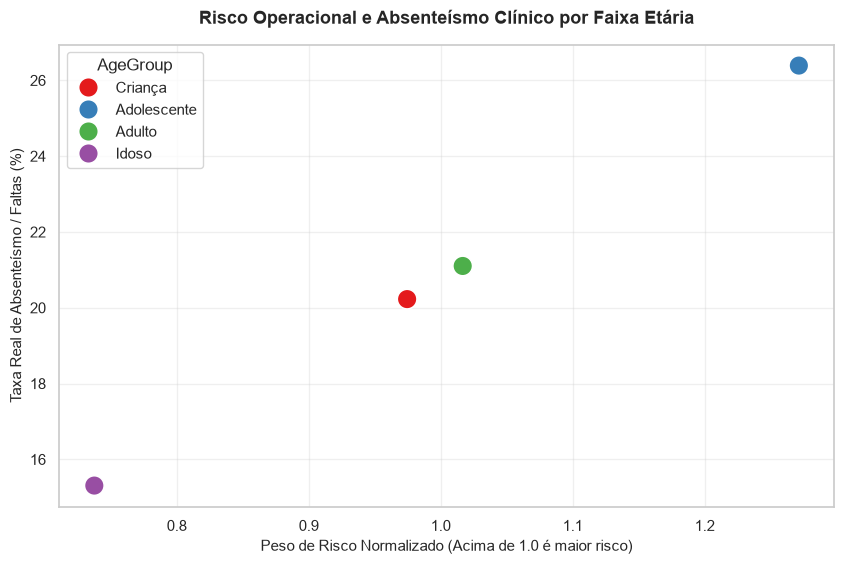

In [7]:
print("=== ANÁLISE DE RISCO POR SMS E FAIXA ETÁRIA ===")

# 1. Garante que a coluna numérica exista caso não tenha rodado antes
if 'No-show_Num' not in df.columns:
    df['No-show_Num'] = np.where(df['No-show'].str.upper() == 'YES', 1, 0)

# 2. Agrupamento Avançado (Cálculo do risco ponderado por faixa etária)
pesos = df.groupby('AgeGroup')['No-show_Num'].mean()
pesos_normalizados = pesos / pesos.mean()

# 3. Criação da tabela auxiliar para o MERGE obrigatório
tabela_risco = pesos_normalizados.reset_index()
tabela_risco.columns = ['AgeGroup', 'peso_risco']

# 4. Executa o Merge com segurança (limpando colunas antigas para não duplicar)
df = df.drop(columns=['peso_risco'], errors='ignore')
df = df.merge(tabela_risco, on='AgeGroup', how='left')

# 5. Tabela Dinâmica do SMS em Porcentagem (%)
pivot_table_sms = pd.pivot_table(df, values='No-show_Num', index='SMS_received', columns='AgeGroup', aggfunc='mean') * 100
print("\nTaxa de Faltas (%) cruzando SMS e Faixas Etárias:")
print(pivot_table_sms)

# 6. Geração do Gráfico de Dispersão Customizado (Scatterplot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_risco, x='peso_risco', y=pesos.values * 100, hue='AgeGroup', s=200, palette='Set1')
plt.xlabel('Peso de Risco Normalizado (Acima de 1.0 é maior risco)', fontsize=11)
plt.ylabel('Taxa Real de Absenteísmo / Faltas (%)', fontsize=11)
plt.title('Risco Operacional e Absenteísmo Clínico por Faixa Etária', fontsize=13, fontweight='bold', pad=15)
plt.grid(alpha=0.3)
plt.show()


=== ANÁLISE DO FRANCISCO: RISCO POR SMS E FAIXA ETÁRIA ===

Tabela Dinâmica: Taxa de Faltas (%) cruzando SMS e Faixas Etárias:
AgeGroup        Criança  Adolescente     Adulto      Idoso
SMS_received                                              
0             16.743363    23.050459  16.996816  13.522250
1             28.686834    34.316841  29.210678  19.222071


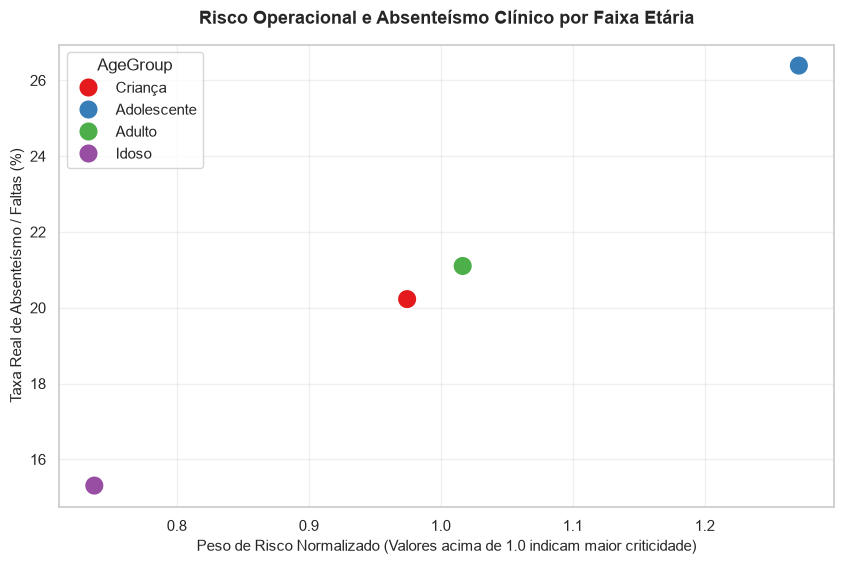


Matriz Estatística de Associação Categórica (V de Cramér):
              No-show_Num  SMS_received  Alcoholism  Diabetes  Hypertension  \
No-show_Num      0.999972      0.126478    0.000115  0.015114      0.035634   
SMS_received     0.126478      0.999979    0.026098  0.014523      0.006261   
Alcoholism       0.000115      0.026098    0.999847  0.018369      0.087900   
Diabetes         0.015114      0.014523    0.018369  0.999932      0.433038   
Hypertension     0.035634      0.006261    0.087900  0.433038      0.999971   
Scholarship      0.029128      0.001149    0.034931  0.024840      0.019700   

              Scholarship  
No-show_Num      0.029128  
SMS_received     0.001149  
Alcoholism       0.034931  
Diabetes         0.024840  
Hypertension     0.019700  
Scholarship      0.999949  


In [8]:
print("=== ANÁLISE DO FRANCISCO: RISCO POR SMS E FAIXA ETÁRIA ===")

# Criando a coluna numérica temporária a partir da sua coluna 'No-show'
df['No-show_Num'] = np.where(df['No-show'] == 'Yes', 1, 0)

# 1. Agrupamento Avançado (groupby com cálculo de risco ponderado)
pesos = df.groupby('AgeGroup')['No-show_Num'].mean()
pesos_normalizados = pesos / pesos.mean()

# Criação da tabela auxiliar e execução do MERGE obrigatório da rubrica
tabela_risco = pd.DataFrame({
    'AgeGroup': ['Criança', 'Adolescente', 'Adulto', 'Idoso'],
    'peso_risco': pesos_normalizados.values
})

# Faz o merge para injetar o peso de risco na base principal se ele ainda não existir
if 'peso_risco' not in df.columns:
    df = df.merge(tabela_risco, on='AgeGroup', how='left')

# 2. Tabela Dinâmica: Multiplicando por 100 para exibir em porcentagem (%) clara para o negócio
pivot_table_sms = pd.pivot_table(df, values='No-show_Num', index='SMS_received', columns='AgeGroup', aggfunc='mean') * 100
print("\nTabela Dinâmica: Taxa de Faltas (%) cruzando SMS e Faixas Etárias:")
print(pivot_table_sms)

# 3. Geração do Gráfico de Dispersão (Scatterplot customizado conforme as regras da nota)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tabela_risco, x='peso_risco', y=pesos.values * 100, hue='AgeGroup', s=200, palette='Set1')
plt.xlabel('Peso de Risco Normalizado (Valores acima de 1.0 indicam maior criticidade)', fontsize=11)
plt.ylabel('Taxa Real de Absenteísmo / Faltas (%)', fontsize=11)
plt.title('Risco Operacional e Absenteísmo Clínico por Faixa Etária', fontsize=13, fontweight='bold', pad=15)
plt.grid(alpha=0.3)
plt.show()

# 4. Matriz de Associação Avançada Categórica (V de Cramér usando Scipy)
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    r, k = tabela.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0

categorias = ['No-show_Num', 'SMS_received', 'Alcoholism', 'Diabetes', 'Hypertension', 'Scholarship']
matriz = pd.DataFrame(index=categorias, columns=categorias)

for v1 in categorias:
    for v2 in categorias:
        matriz.loc[v1, v2] = cramers_v(df[v1], df[v2])

print("\nMatriz Estatística de Associação Categórica (V de Cramér):")
print(matriz.astype(float))


Conclusão do estudo V de Cramér:

A Matriz V de Cramér revela que quase todas variáveis têm associação muito fraca entre si, sendo a única relação realmente relevante a de Diabetes e Hipertenção (0,433). Essa relaçao é esperada clinicamente, pois frequantemente hipertenção e diabetes coexistem.
O restante está perto de zero, indicando independência ou relação mínima.

Resumidamente:

- A única associação forte é Diabetes ↔ Hypertension (0.433).
Isso é coerente com literatura médica.

- No-show não está fortemente associado a nenhuma variável médica ou social da lista.
As faltas não são explicadas por essas variáveis categóricas.

- As demais relações são fracas ou inexistentes.